# 📊 Preliminary Exploratory Data Analysis
This exploratory data analysis investigates the raw Instacart Kaggle datasets to inform feature engineering and machine learning model strategy. 

## Key Findings
1. **Long-Tail Sparsity:** The product catalog exhibits extreme sparsity, with the top 20% of items driving roughly 91% of total order volume. This underscores the necessity of high data volume for predictive models to accurately learn the nuanced interactions of the long tail.
2. **Cyclical Order Patterns:** Order density follows a pattern, peaking significantly during Sunday afternoons and Monday mornings. This indicates cyclical order habits for users.
3. **User Types:** Analyzing user footprints reveals a sharp right-skew in distinct products purchased. By calculating a custom "Exploratory Ratio," we can effectively segment users into habitual staple-buyers versus highly exploratory shoppers, providing a strong foundational feature for downstream modeling.

## Overview
 1. Imports & BigFrames Data Loading
 2. Check Data Integrity
 3. Long Tail Distribution (Product Order Volume Sparsity)
 4. Day of Week & Time of Day Order Density Heatmap
 5. Total Orders per User & Distinct Products per User Distributions
 6. User Exploratory Ratio Distribution

<div style="background-color: #fef7e0; border-left: 4px solid #b06000; color: #b06000; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>⚠️ Dependency Note:</strong> VM service account Big Query permission in IAM is required (Admin or Job User & Data Viewer)
</div>

### 1. Imports & BigFrames Data Loading
Perform imports, load big query raw Instacart data into a BigFrames

In [1]:
import bigframes.pandas as bpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [2]:
# Set plotting style for clean visuals
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

<div style="background-color: #e8f0fe; border-left: 4px solid #1a73e8; color: #1c3d5a; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>🛠️ Strategy:</strong> Due to the size of the raw data,  I am utilizing BigFrames to keep execution and aggregations in the BigQuery engine as long as possible to improve performance.
</div>

In [3]:
# 1. Initialize BigQuery connection strings
bpd.options.bigquery.project = "instacart-ml-model"
bpd.options.bigquery.location = "US"

# Load data into BigFrame
bf_orders = bpd.read_gbq("instacart-ml-model.instacart.orders")
bf_products = bpd.read_gbq("instacart-ml-model.instacart.products")
bf_order_products_prior = bpd.read_gbq("instacart-ml-model.instacart.order_products__prior")
bf_order_products_train = bpd.read_gbq("instacart-ml-model.instacart.order_products__train")

bf_order_products = bpd.concat([bf_order_products_prior, bf_order_products_train], ignore_index = True)

print(f"Orders shape: {bf_orders.shape}")
print(f"Products shape: {bf_products.shape}")
print(f"Order Products shape: {bf_order_products.shape}")

Orders shape: (3421083, 7)


Products shape: (49688, 4)


Order Products shape: (33819106, 4)


### 2. Check Data Integrity
Check data type, summary statistics, null values, and duplicates 

In [4]:
for name, bf in [('Orders', bf_orders), ('Products', bf_products), ('Order Products', bf_order_products)]:
    print(f"\n--- {name} BigFrame ---")
    display(bf.info()) 
    
    print("\n=== RAW SUMMARY STATISTICS ===")
    display(bf.describe()) 

    print("\n=== NULL VALUE CHECK ===")
    display(bf.isnull().sum())

    print("\n=== DUPLICATES CHECK ===")
    display(bf.duplicated().sum())



--- Orders BigFrame ---
<class 'bigframes.dataframe.DataFrame'>


Index: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
  #  Column                  Dtype
---  ----------------------  -------
  0  order_id                Int64
  1  user_id                 Int64
  2  eval_set                string
  3  order_number            Int64
  4  order_dow               Int64
  5  order_hour_of_day       Int64
  6  days_since_prior_order  Float64
dtypes: Float64(1), Int64(5), string(1)


memory usage: 218949312 bytes


None


=== RAW SUMMARY STATISTICS ===


...

,order_id,product_id,add_to_cart_order,reordered
count,33819106.0,33819106.0,33819106.0,33819106.0
mean,1710566.29092,25575.51453,8.367738,0.590062
std,987400.761933,14097.696774,7.13954,0.491822
min,1.0,1.0,1.0,0.0
25%,863031.0,13629.0,3.0,0.0
50%,1718841.0,25466.0,6.0,1.0
75%,2571460.0,38159.0,12.0,1.0
max,3421083.0,49688.0,145.0,1.0



=== NULL VALUE CHECK ===


order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: Int64


=== DUPLICATES CHECK ===


np.int64(0)

In [5]:
#Validate that all nulls in days_since_prior_order are the first order for a product.
mask = bf_orders['days_since_prior_order'].isnull()

bf_orders_null = bf_orders[mask]

unique_order_nums = bf_orders_null['order_number'].unique().to_pandas()

display(unique_order_nums)

5    1
Name: order_number, dtype: Int64

<div style="background-color: #e6f4ea; border-left: 4px solid #137333; color: #137333; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>💡 Key Insight:</strong> All null values for days_since_prior_order are for a users first order
</div>

### 3. Long Tail Distribution (Product Order Volume Sparsity)

The top 20% of products account for 90.92% of total row volume.


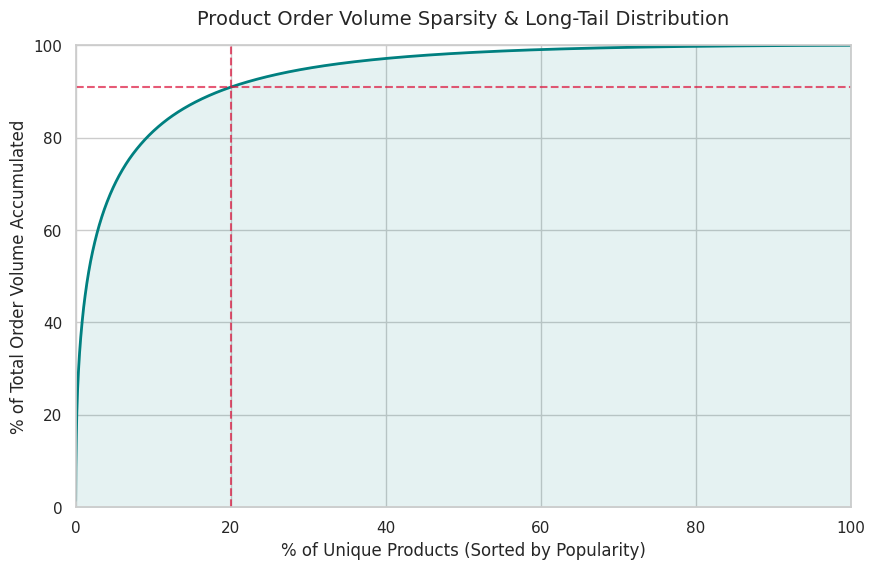

In [6]:
# Group and count entirely in BQ
product_counts_bf = bf_order_products['product_id'].value_counts().sort_values(ascending=False).reset_index()
product_counts_bf.columns = ['product_id', 'order_count']

# Compute totals and cumulative sums
total_orders = bf_order_products.shape[0]
product_counts_bf['cumulative_orders'] = product_counts_bf['order_count'].cumsum()
product_counts_bf['cumulative_orders_pct'] = (product_counts_bf['cumulative_orders'] / total_orders) * 100

#Get Total Unique Products
total_unique_products = bf_products.shape[0]

#Get the cumulative product % (Identify the percentage of total products that have less than or equal to a rows cumulative orders perecentage...
#i.e. 20% of products make up x% of orders) 

product_counts_bf['product_rank'] = bpd.Series(np.arange(1, len(product_counts_bf) + 1), index=product_counts_bf.index)
product_counts_bf['cumulative_products_pct'] = (product_counts_bf['product_rank'] / total_unique_products) * 100

# Convert to pandas with only the columns needed for plotting
product_counts_pd = product_counts_bf[['cumulative_products_pct', 'cumulative_orders_pct', 'order_count']].to_pandas()

# Create the plot
plt.figure()
plt.plot(product_counts_pd['cumulative_products_pct'], product_counts_pd['cumulative_orders_pct'], color='teal', lw=2)
plt.fill_between(product_counts_pd['cumulative_products_pct'], product_counts_pd['cumulative_orders_pct'], alpha=0.1, color='teal')

# Find where the top 20% of products sit to highlight Pareto's law
mask = product_counts_pd['cumulative_products_pct'] <= 20
top_20_pct_val = product_counts_pd[mask]['cumulative_orders_pct'].max()

plt.axvline(x=20, color='crimson', linestyle='--', alpha=0.7)
plt.axhline(y=top_20_pct_val, color='crimson', linestyle='--', alpha=0.7)
plt.title('Product Order Volume Sparsity & Long-Tail Distribution', fontsize=14, pad=15)
plt.xlabel('% of Unique Products (Sorted by Popularity)', fontsize=12)
plt.ylabel('% of Total Order Volume Accumulated', fontsize=12)
plt.xlim(0, 100)
plt.ylim(0, 100)
print(f"The top 20% of products account for {top_20_pct_val:.2f}% of total row volume.")
plt.show()


<div style="background-color: #e6f4ea; border-left: 4px solid #137333; color: #137333; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>💡 Key Insight:</strong> 20% of products account for 91% of transactions. For the majority of products, orders are sparse.
</div>

<div style="background-color: #e8f0fe; border-left: 4px solid #1a73e8; color: #1c3d5a; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>🛠️ Strategy:</strong> I will prioritize data volume over extensive hyperparameter tuning of models. Tree-based models like Random Forest, XGBoost, and LightGBM need exposure to enough transactions to learn patterns for the less frequently orderd products.
</div>

### 4. Day of Week & Time of Day Order Density Heatmap

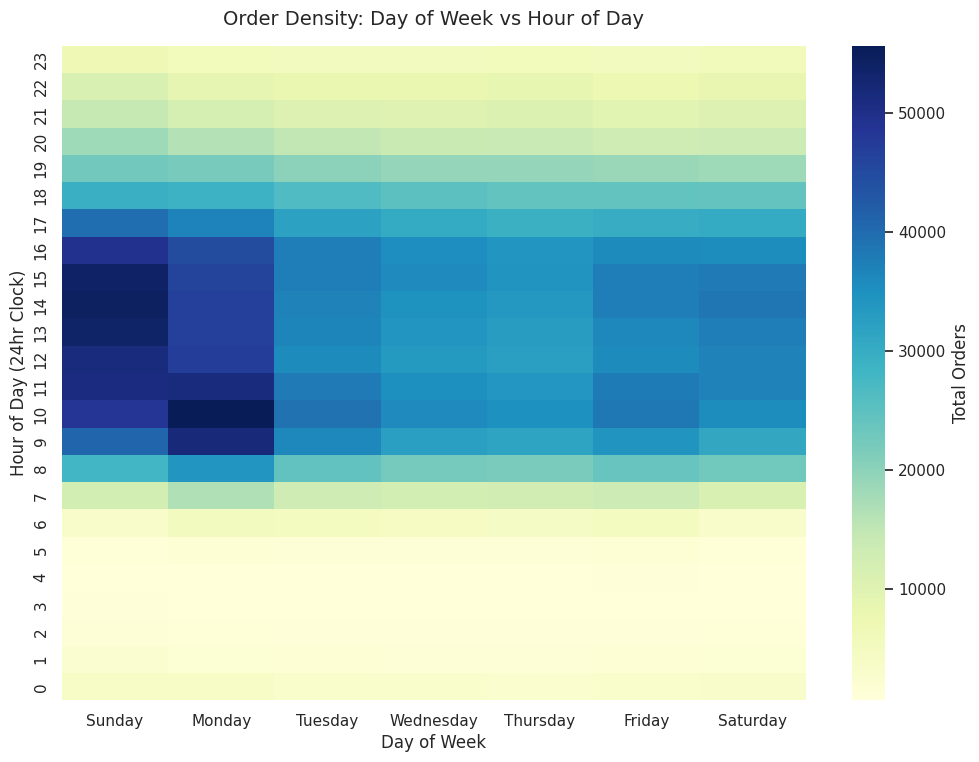

In [7]:

#Get order count by day of week and time of day
time_bf = bf_orders.groupby(['order_dow', 'order_hour_of_day']).size().reset_index()
time_bf.columns = ['order_dow', 'order_hour_of_day', 'order_count']

#Convert to pandas and pivot data
time_pd = time_bf.to_pandas()
plot_matrix = time_pd.pivot(index='order_hour_of_day', columns='order_dow', values='order_count')

#Fill nulls with 0 and convert to float
plot_matrix = plot_matrix.fillna(0).astype(float)

#Create List for day of week labels
day_labels = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

plt.figure(figsize=(12, 8.5))
sns.heatmap(plot_matrix, cmap='YlGnBu', xticklabels=day_labels, yticklabels=True, cbar_kws={'label': 'Total Orders'})
plt.title('Order Density: Day of Week vs Hour of Day', fontsize=14, pad=15)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Hour of Day (24hr Clock)', fontsize=12)

#Invert the y-axis so it starts with 0
plt.gca().invert_yaxis()

plt.show()

<div style="background-color: #e6f4ea; border-left: 4px solid #137333; color: #137333; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>💡 Key Insight:</strong> Order density peaks Sunday afternoons & Monday mornings.
</div>

### 5. Total Orders per User & Distinct Products per User Distributions

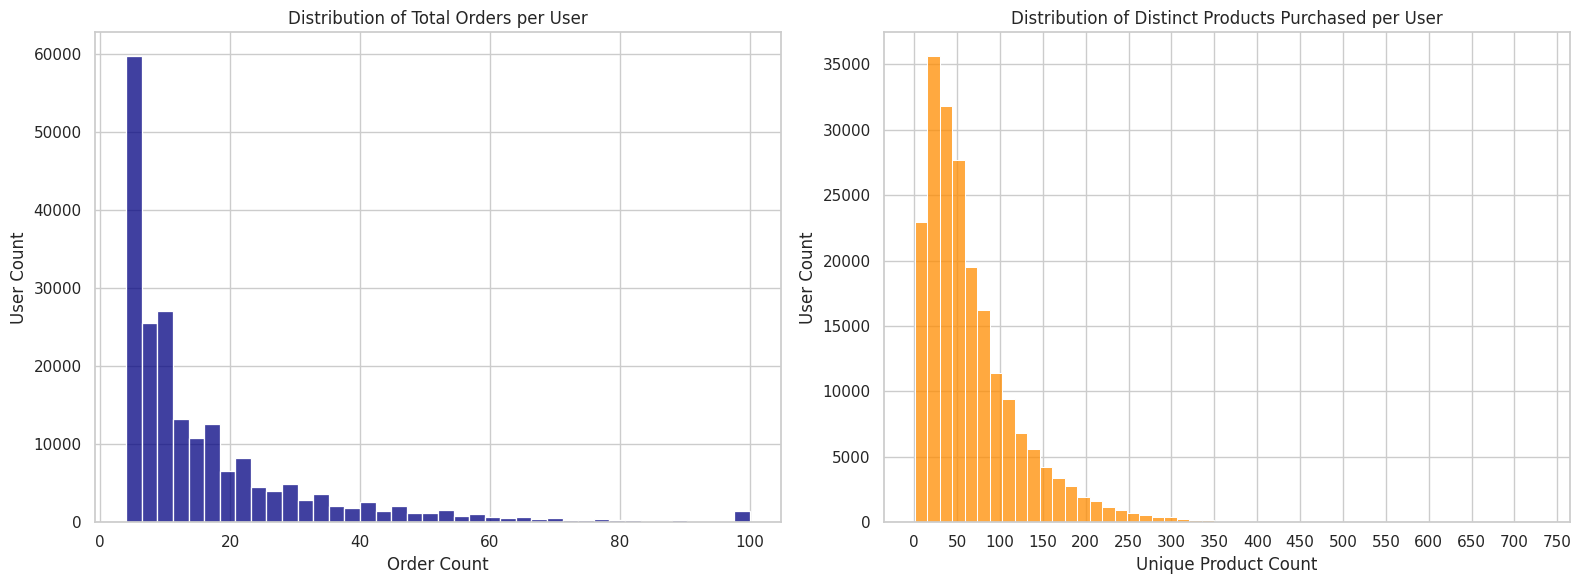

In [8]:
# Get order counts by user
user_total_orders_bf = bf_orders.groupby('user_id')['order_number'].max().reset_index()
user_total_orders_pd = user_total_orders_bf['order_number'].to_pandas()

# Join files on BigQuery before computing metrics per user
user_items_bf = bf_order_products[['order_id', 'product_id']].merge(bf_orders[['order_id', 'user_id']], on='order_id')
distinct_products_per_user_bf = user_items_bf.groupby('user_id')['product_id'].nunique().reset_index()
distinct_products_per_user_bf.columns = ['user_id', 'distinct_products']
distinct_products_per_user_df = distinct_products_per_user_bf['distinct_products'].to_pandas()

# Plot the pre-aggregated user distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(user_total_orders_pd, bins=40, kde=False, color='navy', ax=axes[0])
axes[0].set_title('Distribution of Total Orders per User', fontsize=12)
axes[0].set_xlabel('Order Count')
axes[0].set_ylabel('User Count')

sns.histplot(distinct_products_per_user_df, bins=50, kde=False, color='darkorange', ax=axes[1])
axes[1].set_title('Distribution of Distinct Products Purchased per User', fontsize=12)
axes[1].set_xlabel('Unique Product Count')
axes[1].set_ylabel('User Count')

#set ticks every 50 for x-axis
axes[1].xaxis.set_major_locator(ticker.MultipleLocator(50))

plt.tight_layout()
plt.show()

<div style="background-color: #e6f4ea; border-left: 4px solid #137333; color: #137333; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>💡 Key Insight:</strong> The order distribution is heavily right-skewed, indicating a group of power users, while the sharp cutoff at 100 max orders suggests data clipping in the raw dataset. 
</div>

<div style="background-color: #e6f4ea; border-left: 4px solid #137333; color: #137333; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>💡 Key Insight:</strong> The distinct product distribution is also heavily right-skewed. This indicates that most customers order staple groceries for the majority of their shopping, while only a minority of users explore hundreds of unique items.
</div>

### 6. User Exploratory Ratio Distribution

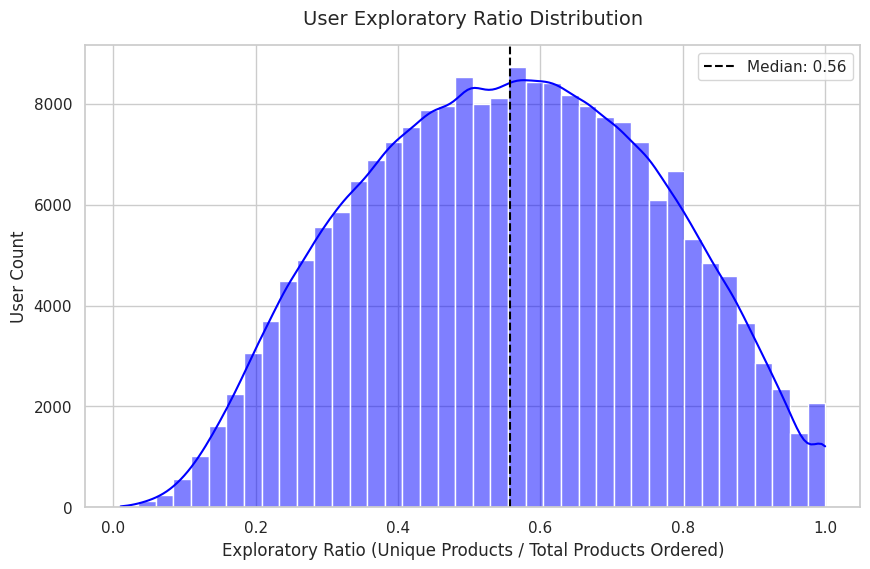

In [10]:
#Get total transactions and total distinct products by user id
user_products_bf = user_items_bf.groupby('user_id').agg(total_transactions=('product_id', 'count'), distinct_products=('product_id', 'nunique'))

#Get exploratory_ratio (does a user frequently explore new products?)
user_products_bf['exploratory_ratio'] = user_products_bf['distinct_products'] / user_products_bf['total_transactions']

# Convert to pandas
exploratory_ratio_pd = user_products_bf['exploratory_ratio'].to_pandas()

plt.figure()
sns.histplot(exploratory_ratio_pd, bins=40, kde=True, color='blue')
plt.title('User Exploratory Ratio Distribution', fontsize=14, pad=15)
plt.xlabel('Exploratory Ratio (Unique Products / Total Products Ordered)', fontsize=12)
plt.ylabel('User Count', fontsize=12)

#add median line
median_value = exploratory_ratio_pd.median()
plt.axvline(median_value, color='black', linestyle='--', label=f"Median: {median_value:.2f}")

plt.legend()
plt.show()


<div style="background-color: #e6f4ea; border-left: 4px solid #137333; color: #137333; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>💡 Key Insight:</strong> The exploratory ratio reveals shopper types. Users with higher ratios explore new items frequently, while users with lower ratios are more habitual shoppers.
</div>